# Script for generating publication-quality figures


In [9]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import sympy as sp
from functional import BetterColor, simulate

from acrobot_inverse_kinematics import inverse_kinematics
from k1_acrobot_cdc2026 import k1_0, k1_1, y, val_lambda, val_delta

In [10]:
x = sp.symbols("x:4")
params = {
    "m1": 1.0,
    "m2": 1.0,  # Mass of links
    "l1": 4.0,
    "l2": 4.0,  # Length of links
    "lc1": 2.0,
    "lc2": 2.0,  # Center of mass positions
    "I1": 0.02,
    "I2": 0.02,  # Moments of inertia
    "g": 9.81,  # Gravity
}

m1, m2 = params["m1"], params["m2"]
l1, l2 = params["l1"], params["l2"]
lc1, lc2 = params["lc1"], params["lc2"]
I1, I2 = params["I1"], params["I2"]
g = params["g"]

# Mass (Inertia) Matrix M(q)
M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * sp.cos(x[1]))
M12 = m2 * (lc2**2 + l1 * lc2 * sp.cos(x[1])) + I2
M21 = M12
M22 = m2 * lc2**2 + I2
M = sp.Matrix([[M11, M12], [M21, M22]])

# Coriolis and Centrifugal Matrix C(q, q_dot)
C11 = -m2 * l1 * lc2 * sp.sin(x[1]) * x[3]
C12 = -m2 * l1 * lc2 * sp.sin(x[1]) * (x[2] + x[3])
C21 = m2 * l1 * lc2 * sp.sin(x[1]) * x[2]
C22 = 0
C = sp.Matrix([[C11, C12], [C21, C22]])

# Gravity Matrix G(q)
G1 = (m1 * g * lc1 + m2 * g * l1) * sp.cos(x[0]) + m2 * g * lc2 * sp.cos(x[0] + x[1])
G2 = m2 * g * lc2 * sp.cos(x[0] + x[1])
G = sp.Matrix([G1, G2])

f0 = x[2]
f1 = x[3]
f2f3 = -M.inv() @ (C @ sp.Matrix([x[2], x[3]]) + G)
Z = sp.zeros(2, 2)

f = sp.Matrix.vstack(sp.Matrix([f0, f1]), f2f3)
g = sp.Matrix.vstack(Z, M.inv())
k1 = sp.Matrix([k1_0, k1_1])

psi_y = sp.Matrix([-((4 * (y[0] - 2) - 2 * y[1] ** 3) ** 2) + 0.8 * y[1] ** 3 + 10])
h = sp.Matrix(
    [
        l1 * sp.cos(x[0]) + l2 * sp.cos(x[0] + x[1]),
        l1 * sp.sin(x[0]) + l2 * sp.sin(x[0] + x[1]),
    ]
)  # 2*1 column vector

Lfh = h.jacobian(x) @ f

F = Lfh.jacobian(x) @ f
G = Lfh.jacobian(x) @ g

Dy_psi = psi_y.jacobian(y)

mu_1 = 15

item1 = -F
item2 = mu_1 * Dy_psi.T
item3 = k1.jacobian(sp.Matrix([y[0], y[1]])) @ Lfh
item4 = val_lambda / 2 * (Lfh - k1)
item2 = item2.subs({y[0]: h[0], y[1]: h[1]})
item3 = item3.subs({y[0]: h[0], y[1]: h[1]})
item4 = item4.subs({y[0]: h[0], y[1]: h[1]})

ku = sp.inv_quick(G) @ (item1 + item2 + item3 + item4)

print("ku:", ku)

dyn_cl = f + g @ ku
dyn_cl_f = sp.lambdify(x, dyn_cl, "numpy")

# safe set and target set
psi = -((4 * (y[0] - 2) - 2 * y[1] ** 3) ** 2) + 0.8 * y[1] ** 3 + 10
phi = (((y[0] - 2) - 3.5) ** 2 / 1.2**2) + ((y[1] - 1.9) ** 2 / 0.4**2) - 2

psi_gamma = sp.Matrix([psi]) - 1 / (2 * mu_1) * (Lfh - k1).T @ (Lfh - k1)

psi_gamma_x = psi_gamma.subs({y[0]: h[0], y[1]: h[1]})
psi_gamma_x = psi_gamma_x[0]
phi_x = phi.subs({y[0]: h[0], y[1]: h[1]})
psi_x = psi.subs({y[0]: h[0], y[1]: h[1]})

# initial admissible configurations
np.random.seed(5)
ys = np.random.random((2, 500)) * 2 * np.sqrt(l1**2 + l2**2) - np.sqrt(l1**2 + l2**2)
pts = np.empty((4, 0))

for i in range(ys.shape[1]):
    (q1_1, q2_1), (q1_2, q2_2) = inverse_kinematics(ys[0, i], ys[1, i], l1, l2)
    pts = np.column_stack((pts, np.array([q1_1, q2_1, 0, 0])))

psi_fx = sp.lambdify(x, psi_x, "numpy")
phi_fx = sp.lambdify(x, phi_x, "numpy")
psi_gamma_fx = sp.lambdify(x, psi_gamma_x, "numpy")


def psi_gamma_fx_01(y0, y1):
    (x0, x1), (x0_2, x1_2) = inverse_kinematics(y0, y1, l1=l1, l2=l2)
    return psi_gamma_fx(x0, x1, 0, 0)


vals_psi_gamma = psi_gamma_fx(*pts)
psi_vals = psi_fx(*pts)
phi_vals = phi_fx(*pts)

index = np.nonzero((psi_vals >= 0) & (phi_vals > 0) & (vals_psi_gamma >= 0))

pts_init = pts[:, index].squeeze(axis=1)

print(pts_init.shape)  # valid initial x states

ku: Matrix([[(-(-4.0*sin(x0) - 4.0*sin(x0 + x1))*(8.0*cos(x1) + 4.02)/(64.0*cos(x1)**2 - 80.4804) + 4.0*(-16.0*cos(x1) - 24.04)*sin(x0 + x1)/(64.0*cos(x1)**2 - 80.4804))*(-x2*(x2*(-4.0*sin(x0) - 4.0*sin(x0 + x1)) - 4.0*x3*sin(x0 + x1)) + 1.03655e-6*x2*(4.0*cos(x0) + 4.0*cos(x0 + x1)) - x3*(-4.0*x2*sin(x0 + x1) - 4.0*x3*sin(x0 + x1)) + 4.1462e-6*x3*cos(x0 + x1) + (x2*(-4.0*sin(x0) - 4.0*sin(x0 + x1)) - 4.0*x3*sin(x0 + x1))*(0.12919*(4.0*sin(x0) + 4.0*sin(x0 + x1))**2 - 0.4224*(4.0*sin(x0) + 4.0*sin(x0 + x1))*(4.0*cos(x0) + 4.0*cos(x0 + x1)) + 0.0059304*(4.0*cos(x0) + 4.0*cos(x0 + x1))**2 - 1.07544*sin(x0) - 1.07544*sin(x0 + x1) + 0.86136*cos(x0) + 0.86136*cos(x0 + x1) + 3.1081) + (x2*(4.0*cos(x0) + 4.0*cos(x0 + x1)) + 4.0*x3*cos(x0 + x1))*(-0.7575*(4.0*sin(x0) + 4.0*sin(x0 + x1))**2 + 0.25838*(4.0*sin(x0) + 4.0*sin(x0 + x1))*(4.0*cos(x0) + 4.0*cos(x0 + x1)) - 0.2112*(4.0*cos(x0) + 4.0*cos(x0 + x1))**2 + 2.47968*sin(x0) + 2.47968*sin(x0 + x1) - 1.07544*cos(x0) - 1.07544*cos(x0 + x1) - 4.

In [11]:
hf = sp.lambdify(x, h, "numpy")

traj_x = []
traj_y = []

dt = 0.01

for i in range(pts_init.shape[-1]):
    # for this point, simulate the trajectory until reach the target set
    x_cur = pts_init[:, i].reshape(1, -1)
    y_cur = hf(*x_cur.T).squeeze(axis=1)

    this_traj_x = [x_cur]
    this_traj_y = [y_cur]

    to_continue = True

    this_phi_val = phi_fx(*x_cur.T).squeeze()

    to_continue = True if this_phi_val > 0 else False

    max_steps = 200

    while to_continue:
        x_next = simulate(dyn_cl_f, x_cur, dt, 3)
        y_next = hf(*x_next.T).squeeze(axis=1)
        this_phi_val = phi_fx(*x_next.T).squeeze()
        to_continue = True if ((this_phi_val > 0) & (max_steps > 0)) else False

        this_traj_x.append(x_cur)
        this_traj_y.append(y_next)

        max_steps -= 1

        x_cur = x_next

        # print(len(this_traj_y))

    this_traj_x = np.stack(this_traj_x).squeeze(axis=1)
    this_traj_y = np.stack(this_traj_y).squeeze(axis=-1)

    print(this_traj_y.shape)

    traj_x.append(this_traj_x)
    traj_y.append(this_traj_y)

(54, 2)
(42, 2)
(50, 2)
(190, 2)
(202, 2)
(124, 2)
(23, 2)
(41, 2)


(2, 2000, 2000) z


/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_13658/3564418175.py:153: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(
/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_13658/3564418175.py:166: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


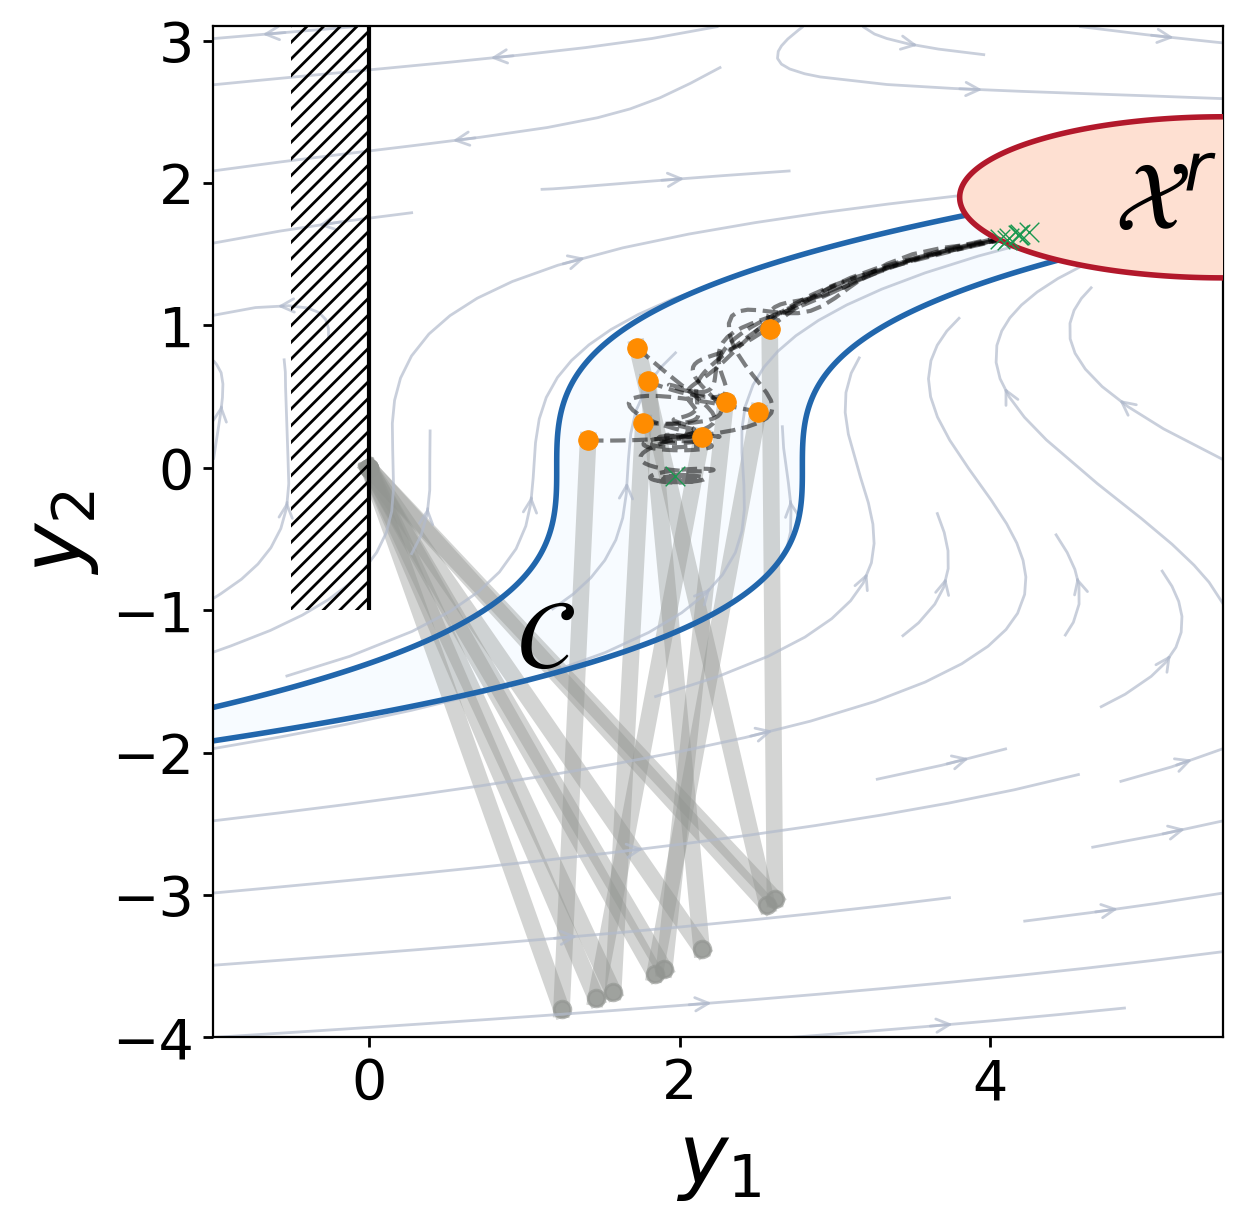

In [12]:
px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(610 * px, 600 * px), layout="constrained")
fig.set_dpi(200)

ny1 = np.linspace(-1, 5.5, 2000)
ny2 = np.linspace(-4, 3.1, 2000)

Y1, Y2 = np.meshgrid(ny1, ny2)

# TAG lambdify function
phi_fy = sp.lambdify(y, phi, "numpy")
psi_fy = sp.lambdify(y, psi, "numpy")

Z_phi = phi_fy(Y1, Y2)
Z_psi = psi_fy(Y1, Y2)
Z_psi_gamma = psi_gamma_fx_01(Y1, Y2)

# vector field of the single-integrator system with k1 controller
k1f = sp.lambdify(y, k1, "numpy")
Z = k1f(Y1, Y2).squeeze()
print(Z.shape, "z")
ax.streamplot(
    Y1,
    Y2,
    Z[0],
    Z[1],
    density=0.5,
    # color="#404040",  # medium gray tone
    # color="#2F4F4F",
    color=BetterColor.gray0(0.7),
    linewidth=1,
    arrowstyle="->",
    arrowsize=1.2,
)

ax.contourf(
    Y1,
    Y2,
    Z_psi,
    levels=[0, +np.inf],
    colors=["#e6f2ff"],  # very light blue
    # hatches=["..."],  # dotted pattern
    alpha=0.3,
    zorder=1,
)

# # ax.contour(Y1, Y2, Z_psi, levels=[0], colors=["black"], alpha=0.7, zorder=1)
# ax.contourf(
#     Y1,
#     Y2,
#     Z_psi,
#     levels=[0, +np.inf],
#     colors=["#e6f2ff"],  # very light blue
#     # hatches=["..."],  # dotted pattern
#     alpha=0.3,
#     zorder=1,
# )

# ax.contourf(
#     Y1,
#     Y2,
#     Z_psi_gamma,
#     levels=[0, +np.inf],
#     colors=["#68bd55"],  #
#     # hatches=["..."],  # dotted pattern
#     alpha=0.3,
#     zorder=100,
# )

ax.contour(
    Y1,
    Y2,
    Z_psi,
    levels=[0],
    colors=["#2166ac"],  # academic blue
    linewidths=2,
    zorder=2,
)

# contour = ax.contourf(
#     Y1, Y2, Z_psi, levels=np.linspace(0, 20, 5), cmap="Greens", alpha=0.7, zorder=1
# )
# plt.colorbar(contour)

# ax.contourf(
#     Y1,
#     Y2,
#     Z_phi,
#     levels=[-np.inf, 0],
#     alpha=0.5,
#     colors="skyblue",
#     # cmap = "viridis",
#     zorder=2,
# )

ax.contourf(
    Y1,
    Y2,
    Z_phi,
    levels=[-np.inf, 0],
    colors=["#fee0d2"],  # light coral
    # hatches=["////"],  # diagonal line pattern
    alpha=1,
    zorder=100,
)
ax.contour(
    Y1,
    Y2,
    Z_phi,
    levels=[0],
    colors=["#b2182b"],  # dark red
    linewidths=2,
    zorder=101,
)

line_style = {
    # "color": "#404040",  # use academic gray instead of pure black
    "color": "#2166ac",
    "linestyle": "-",  # use solid line instead of dash-dot
    "alpha": 0.2,
    "linewidth": 0.5,
    "solid_capstyle": "round",
}

# for i in range(len(traj_y)):
#     print(traj_y[i].shape)
#     print(traj_x[i].shape)
#
# exit(False)

# plot each output trajectory
for i in range(len(traj_y)):
    this_traj_y = traj_y[i]
    # trajectory
    plt.plot(
        this_traj_y[:, 0],
        this_traj_y[:, 1],
        # **line_style,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        zorder=5,
        # "red",
        # linewidth=1.0,
        # alpha=0.4,
        # zorder=2,
    )
    # start point
    # plt.scatter(
    #     this_traj_y[0, 0], this_traj_y[0, 1], s=2, c="black", alpha=0.3, zorder=3
    # )
    plt.scatter(
        this_traj_y[0, 0],
        this_traj_y[0, 1],
        s=50,
        # c="#d73027",  # IEEE red
        c=BetterColor.orange3(),
        # marker="^",  # triangle
        # edgecolor="w",  # white edge
        linewidth=0.3,
        zorder=20,
    )
    # end point
    # plt.scatter(this_traj_y[-1, 0], this_traj_y[-1, 1], s=2.5, c="red", zorder=3)
    plt.scatter(
        this_traj_y[-1, 0],
        this_traj_y[-1, 1],
        s=50,
        linewidth=0.5,
        # c="#313695",  # dark blue
        # c="#8B008B",
        # c="#4daf4a",
        c=BetterColor.green0(),
        # edgecolors="#984ea3",
        # marker="o",  # circle
        # marker=(5, 1, 0),
        marker="x",
        # edgecolor="#ffffbf",  # light yellow edge
        # linewidth=0.4,
        zorder=200,
    )

# for each trajectory, plot the initial motion and final motion

for i in range(len(traj_y)):
    this_traj_x = traj_x[i]
    # plot the initial motion
    q1, q2 = this_traj_x[0, 0], this_traj_x[0, 1]
    x1, y1 = params["l1"] * np.cos(q1), params["l1"] * np.sin(q1)
    x2, y2 = x1 + params["l2"] * np.cos(q1 + q2), y1 + params["l2"] * np.sin(q1 + q2)

    ax.plot(
        [0, x1],
        [0, y1],
        "o-",
        alpha=0.4,
        lw=6,
        # color="blue",
        # color="gray",
        color=BetterColor.gray2(),
        zorder=1,
    )  # First link

    ax.plot(
        [x1, x2],
        [y1, y2],
        "o-",
        # alpha=alpha_value[i // interval],
        alpha=0.4,
        lw=6,
        # color="red",
        # color="gray",
        color=BetterColor.gray2(),
        zorder=1,
    )  # Second link

    # plot the final motion
    # q1, q2 = this_traj_x[-1, 0], this_traj_x[-1, 1]
    # x1, y1 = params["l1"] * np.cos(q1), params["l1"] * np.sin(q1)
    # x2, y2 = x1 + params["l2"] * np.cos(q1 + q2), y1 + params["l2"] * np.sin(
    #     q1 + q2
    # )
    # x2, y2 = traj_y[i][-1, 0], traj_y[i][-1, 1]
    #
    # ax.plot(
    #     [0, x1],
    #     [0, y1],
    #     "-",
    #     alpha=0.2,
    #     lw=6,
    #     # color="blue",
    #     # color="gray",
    #     color=BetterColor.gray2(),
    #     zorder=1,
    # )  # First link
    #
    # ax.plot(
    #     [x1, x2],
    #     [y1, y2],
    #     "o-",
    #     # alpha=alpha_value[i // interval],
    #     alpha=0.2,
    #     lw=6,
    #     # color="red",
    #     # color="gray",
    #     color=BetterColor.purple0(),
    #     zorder=1,
    # )  # Second link

# for i in range(traj_y.shape[-1]):
#     plt.plot(
#         traj_y[:, 0, i], traj_y[:, 1, i], "red", linewidth=1.0, alpha=0.4, zorder=2
#     )

# plt.scatter(traj_y[0, 0, :], traj_y[0, 1, :], s=1.5, c="black", alpha=0.3, zorder=3)
# plt.scatter(traj_y[-1, 0, :], traj_y[-1, 1, :], s=2.5, c="red", zorder=3)
# ax.scatter([0.0], [0.0], s=50, c="black", zorder=6)
# plt.text(0.0, 0.1, "Origin", fontsize=12, color="black")
# plt.axis("equal")
# plt.autoscale(tight=True)

# Draw the Wall
# wall_front = ax.vlines(-0.2, -1, 1, colors="black")

width_hatch = 0.5
wall_back = ax.vlines(-width_hatch + width_hatch, -1, 3.1, colors="black")
height_hatch = 4.1
xy_hatch = (-width_hatch, -1)
wall_hatch = Rectangle(
    xy_hatch,
    width_hatch,  # width
    height_hatch,  # height
    facecolor="None",
    linestyle="None",
    hatch="////",
    zorder=1000,
)
ax.add_patch(wall_hatch)

this_fontsize = 35

ax.text(0.95, -1.4, "$\mathcal{C}$", zorder=100, fontsize=this_fontsize)
ax.text(4.8, 1.67, "$\mathcal{X}^r$", zorder=1000, fontsize=this_fontsize)
# temp_str = "$\mathcal{C}_{\Psi," + str(mu_1) + "}$"
# ax.text(1.58, -0.18, temp_str, zorder=100, fontsize=this_fontsize - 2)

# ax.annotate(
#     "$\mathcal{X}^r$",
#     xy=(1.65, -0.6),
#     xytext=(-0.5, -1.5),
#     arrowprops=dict(facecolor="black", shrink=0.01, width=0.1, headwidth=5),
#     horizontalalignment="left",
#     verticalalignment="bottom",
#     fontsize=this_fontsize,
# )

ax.xaxis.set_tick_params(labelsize=20, width=1)
ax.yaxis.set_tick_params(labelsize=20, width=1)
plt.xlabel("$y_1$", fontsize=this_fontsize - 5)
plt.ylabel("$y_2$", fontsize=this_fontsize - 5)
# plt.title("2-DoF Planar Link Safety-Critical Control")
# plt.grid()

plt.show()

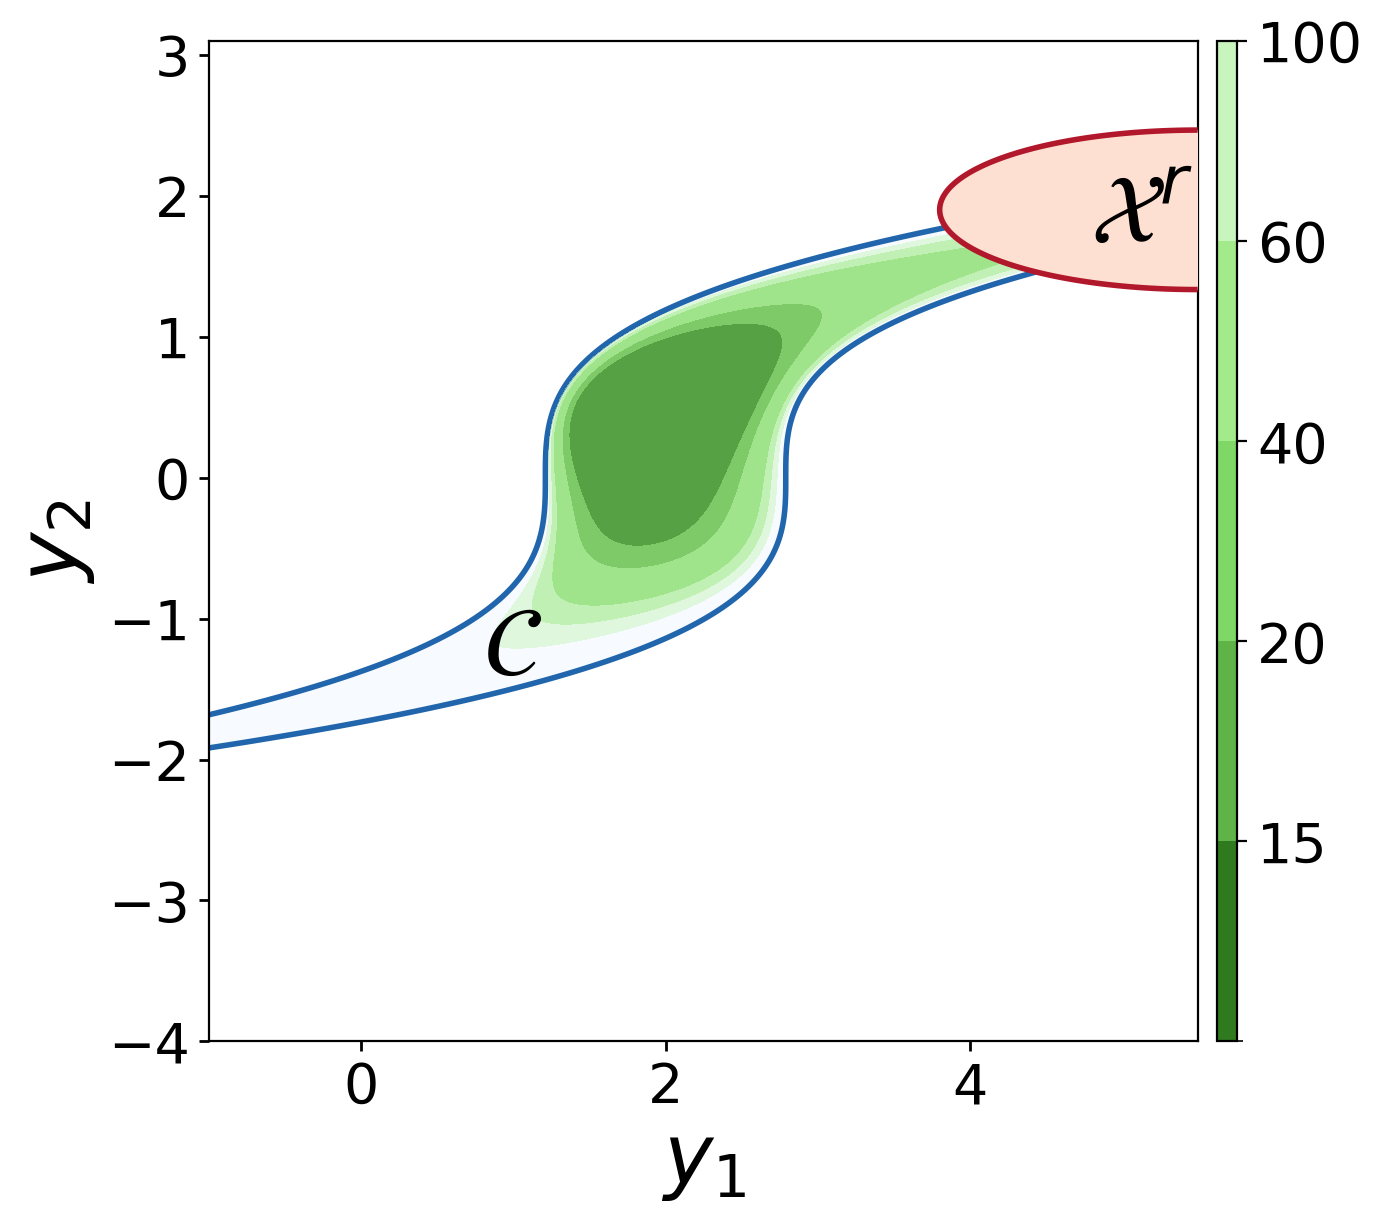

In [13]:
import matplotlib.colors as mcolors


def compute_psi_gamma(mu_1, psi, Lfh, k1):

    psi_gamma = sp.Matrix([psi]) - 1 / (2 * mu_1) * (Lfh - k1).T @ (Lfh - k1)

    psi_gamma_x = psi_gamma.subs({y[0]: h[0], y[1]: h[1]})
    psi_gamma_x = psi_gamma_x[0]

    psi_gamma_fx = sp.lambdify(x, psi_gamma_x, "numpy")

    def psi_gamma_fx_01(y0, y1):
        (x0, x1), (x0_2, x1_2) = inverse_kinematics(y0, y1, l1=l1, l2=l2)
        return psi_gamma_fx(x0, x1, 0, 0)

    return psi_gamma_fx_01


px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(680 * px, 600 * px), layout="constrained")
fig.set_dpi(200)

ny1 = np.linspace(-1, 5.5, 2000)
ny2 = np.linspace(-4, 3.1, 2000)

Y1, Y2 = np.meshgrid(ny1, ny2)
phi_fy = sp.lambdify(y, phi, "numpy")
psi_fy = sp.lambdify(y, psi, "numpy")

Z_phi = phi_fy(Y1, Y2)
Z_psi = psi_fy(Y1, Y2)

mu_1_values = np.array([100, 60, 40, 20, 15])
colour_values = ["#c8f5bd", "#a3ea8a", "#7fd765", "#5fb347", "#2f7a1f"]
cmap = mcolors.ListedColormap(colour_values[::-1])
bounds = [0, 15, 20, 40, 60, 100]  # Adjusted to center each number in a color range
norm = mcolors.BoundaryNorm(bounds, cmap.N)

Z_psi_gamma_values = []

for mu_1 in mu_1_values:
    psi_gamma_fx_01 = compute_psi_gamma(mu_1, psi, Lfh, k1)
    Z_psi_gamma = psi_gamma_fx_01(Y1, Y2)
    Z_psi_gamma_values.append(Z_psi_gamma)

# # vector field of the single-integrator system with k1 controller
# k1f = sp.lambdify(y, k1, "numpy")
# Z = k1f(Y1, Y2).squeeze()
# ax.streamplot(
#     Y1,
#     Y2,
#     Z[0],
#     Z[1],
#     density=1.5,
#     # color="#404040",  # Medium gray tone
#     # color="#2F4F4F",
#     color=BetterColor.gray0(0.4),
#     linewidth=1,
#     arrowstyle="->",
#     arrowsize=1.2,
# )

ax.contourf(
    Y1,
    Y2,
    Z_psi,
    levels=[0, +np.inf],
    colors=["#e6f2ff"],  # Very light blue
    # hatches=["..."],  # Dotted pattern
    alpha=0.3,
    zorder=1,
)

ax.contour(
    Y1,
    Y2,
    Z_psi,
    levels=[0],
    colors=["#2166ac"],  # Academic blue
    linewidths=2,
    zorder=2,
)

for i, Z_psi_gamma in enumerate(Z_psi_gamma_values):
    ax.contourf(
        Y1,
        Y2,
        Z_psi_gamma,
        levels=[0, +np.inf],
        colors=colour_values[i],
        alpha=0.5,
        zorder=100,
    )

# Create ScalarMappable and Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# from mpl_toolkits.axes_grid1 import make_axes_locatable
#
# divider = make_axes_locatable(ax)
#
# ax_cb = divider.append_axes("right", size="5%", pad=0.05)
# fig = ax.get_figure()
# fig.add_axes(ax_cb)

cbar = plt.colorbar(
    sm,
    ax=ax,
    # cax=ax_cb,
    orientation="vertical",
    ticks=mu_1_values,
    # fraction=0.1,
    # size="5%",
    pad=0.02,
    aspect=50,
)
cbar.ax.tick_params(labelsize=20)

# Set colorbar label
# cbar.set_label("Starting $\mathcal{C}_\Psi$ for different $\mu$ values")

ax.contourf(
    Y1,
    Y2,
    Z_phi,
    levels=[-np.inf, 0],
    colors=["#fee0d2"],  # Light coral color
    # hatches=["////"],  # Diagonal line pattern
    alpha=1,
    zorder=100,
)
ax.contour(
    Y1,
    Y2,
    Z_phi,
    levels=[0],
    colors=["#b2182b"],  # Dark red
    linewidths=2,
    zorder=101,
)

# width_hatch = 0.5
# wall_back = ax.vlines(-width_hatch + width_hatch, -1, 3.1, colors="black")
# height_hatch = 4.1
# xy_hatch = (-width_hatch, -1)
# wall_hatch = Rectangle(
#     xy_hatch,
#     width_hatch,  # width
#     height_hatch,  # height
#     facecolor="None",
#     linestyle="None",
#     hatch="////",
#     zorder=1000,
# )
# ax.add_patch(wall_hatch)

this_fontsize = 35

ax.text(0.8, -1.4, "$\mathcal{C}$", zorder=100, fontsize=this_fontsize)
ax.text(4.8, 1.67, "$\mathcal{X}^r$", zorder=100, fontsize=this_fontsize)

ax.xaxis.set_tick_params(labelsize=20, width=1)
ax.yaxis.set_tick_params(labelsize=20, width=1)
plt.xlabel("$y_1$", fontsize=this_fontsize - 5, fontname="Times New Roman")
plt.ylabel("$y_2$", fontsize=this_fontsize - 5, fontname="Times New Roman")
# plt.title("2-DoF Planar Link Safety-Critical Control")
# plt.grid()

plt.show()